# Beer Expert Panel — Proper Experiment (2× Augmentation, Full DCR + PCD X–Y)
## Bootstrapping · KDE · Gaussian Copula · VAE · CTGAN · TabDDPM  
### (Style-stratified split · Shrinkage correlation · TSTR/TRTR/AUG · Descriptor-wise rank)

이 노트북은 **“시간이 걸려도 제대로 된 실험”**을 목표로, 이전 v2에서 제안했던 개선점을 모두 포함합니다.

---

## 핵심 설정(이번 요청 반영)

- **증강 데이터 수 2배**:  
  기본값 `AUG_SYN_MULTIPLIER = 2` → 합성 데이터 수 = `2 × N_train`  
  > 만약 “전체 학습 데이터 크기를 2배(=합성=N_train)”로 의도했다면 `AUG_SYN_MULTIPLIER = 1`로 바꾸세요.

- **DCR / PCD X–Y 포함**  
  - DCR: X공간에서 synthetic→real 최단거리 분포
  - PCD: 상관구조 차이  
    - X–X(화학–화학)  
    - **X–Y(화학–관능)** (핵심)  
  - 상관행렬은 **Ledoit–Wolf shrinkage**로 안정화합니다.

- **유용성/증강효과까지 평가**  
  - TRTR(Real→Real)  
  - TSTR(Syn→Real)  
  - AUG(Real+Syn→Real) + 증강 이득(Δ)

- **Downstream predictor(예측모델)**  
  - 기본: GBDT(HistGradientBoostingRegressor; multi-output)  
  - 비교: Torch MLP(GPU)

- **모델 저장 + 결과 파일은 현재시간(RUN_ID) 기반 저장**
  - `outputs/RUN_ID/` 폴더에 저장됩니다.

---

## 실행 순서
1) `0) Paths & Config` 셀에서 경로/설정 확인  
2) 위에서 아래로 실행  
3) 결과는 `outputs/RUN_ID/` 아래 생성됩니다.

---

## 선택 설치(CTGAN)
CTGAN까지 돌리려면 아래 중 하나 설치:
```bash
pip install sdv
# 또는
pip install ctgan
```
설치 후 커널 재시작 권장.

## 0) Paths & Config (RUN_ID 포함)

In [1]:

from pathlib import Path
from datetime import datetime
import sys, platform, json

# === USER PATH ===
DATA_DIR = Path(r"C:\Users\eys63\Desktop\맥주데이터실험\data")
XLSX_PATH = DATA_DIR / "Supplemental Files and Figure source files.xlsx"

# fallback: notebook folder
if not XLSX_PATH.exists():
    alt = Path("Supplemental Files and Figure source files.xlsx")
    if alt.exists():
        XLSX_PATH = alt

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_ROOT = DATA_DIR / "outputs/gpt"
OUT_ROOT.mkdir(parents=True, exist_ok=True)
RUN_DIR = OUT_ROOT / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("XLSX_PATH:", XLSX_PATH, "| exists:", XLSX_PATH.exists())
print("RUN_ID:", RUN_ID)
print("RUN_DIR:", RUN_DIR)

# === EXPERIMENT KNOBS ===
MODE = "minmax_only"            # "minmax_only" or "shift_log1p_minmax"
AUG_SYN_MULTIPLIER = 2          # synthetic = 2×N_train  (set 1 for total train size ≈2×)
REPEATS = 3                     # set 3 for more robust results (slower)
RANDOM_SEEDS = [0, 1, 2, 3, 4]   # will use first REPEATS seeds

SAVE_SYNTH_SCALED = False       # can be huge if True
SAVE_CORR_MATRICES = False      # True -> save correlation matrices (npz)
SAVE_KS_TABLE = True

# Training budgets (PROPER)
VAE_MAX_EPOCHS = 2000
VAE_PATIENCE   = 250
TABDDPM_MAX_EPOCHS = 5000
TABDDPM_PATIENCE   = 600
TABDDPM_TIMESTEPS  = 200
CTGAN_EPOCHS        = 300

# DCR
USE_GPU_FOR_DCR = True

cfg = dict(
    RUN_ID=RUN_ID,
    MODE=MODE,
    AUG_SYN_MULTIPLIER=AUG_SYN_MULTIPLIER,
    REPEATS=REPEATS,
    RANDOM_SEEDS=RANDOM_SEEDS[:REPEATS],
    VAE_MAX_EPOCHS=VAE_MAX_EPOCHS,
    VAE_PATIENCE=VAE_PATIENCE,
    TABDDPM_MAX_EPOCHS=TABDDPM_MAX_EPOCHS,
    TABDDPM_PATIENCE=TABDDPM_PATIENCE,
    TABDDPM_TIMESTEPS=TABDDPM_TIMESTEPS,
    CTGAN_EPOCHS=CTGAN_EPOCHS,
)

with open(RUN_DIR / f"{RUN_ID}__config.json", "w", encoding="utf-8") as f:
    json.dump(cfg, f, ensure_ascii=False, indent=2)

print("Saved config:", RUN_DIR / f"{RUN_ID}__config.json")

Python: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
Platform: Windows-10-10.0.26200-SP0
XLSX_PATH: C:\Users\eys63\Desktop\맥주데이터실험\data\Supplemental Files and Figure source files.xlsx | exists: True
RUN_ID: 20260121_061755
RUN_DIR: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gpt\20260121_061755
Saved config: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gpt\20260121_061755\20260121_061755__config.json


## 1) Imports + CUDA/AMP (4090 eGPU)

In [2]:

import os, math, time, random, gc
import numpy as np
import pandas as pd

from scipy import stats
from scipy.stats import norm

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.covariance import LedoitWolf
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import cloudpickle

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", DEVICE)
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM(GB):", torch.cuda.get_device_properties(0).total_memory / 1e9)

USE_AMP = (DEVICE.type == "cuda")
AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16
SCALER = torch.cuda.amp.GradScaler(enabled=(USE_AMP and AMP_DTYPE == torch.float16))
print("USE_AMP =", USE_AMP, "| AMP_DTYPE =", AMP_DTYPE, "| GradScaler enabled =", SCALER.is_enabled())

def clear_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

DEVICE = cuda
GPU: NVIDIA GeForce RTX 4090
VRAM(GB): 25.756696576
USE_AMP = True | AMP_DTYPE = torch.bfloat16 | GradScaler enabled = False


C:\Users\eys63\AppData\Local\Temp\ipykernel_7576\4068849320.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  SCALER = torch.cuda.amp.GradScaler(enabled=(USE_AMP and AMP_DTYPE == torch.float16))


## 2) Load Data (S1 + S4) — Expert Panel only
- X: `acetaldehyde` ~ `sulfur_sum`
- Y: `A_malt_all` ~ `overall`
- join key: `beer_id`

In [3]:

xls = pd.ExcelFile(XLSX_PATH)
chem  = xls.parse("Supplementary File S1").set_index("beer_id")
panel = xls.parse("Supplementary File S4").set_index("beer_id")

META_COLS = [c for c in ["beer", "tasting_category_fine"] if c in chem.columns]

def slice_range_columns(cols, start, end):
    cols = list(cols)
    if (start not in cols) or (end not in cols):
        raise KeyError(f"Column range not found: {start}..{end}")
    i0, i1 = cols.index(start), cols.index(end)
    if i0 <= i1:
        return cols[i0:i1+1]
    return cols[i1:i0+1]

X_COLS = slice_range_columns(chem.columns, "acetaldehyde", "sulfur_sum")
Y_COLS = slice_range_columns(panel.columns, "A_malt_all", "overall")

df = chem[META_COLS + X_COLS].join(panel[Y_COLS], how="inner")
print("Merged df:", df.shape)
print("X dim:", len(X_COLS), "| Y dim:", len(Y_COLS))
df.head(2)

Merged df: (250, 283)
X dim: 231 | Y dim: 50


,beer,tasting_category_fine,acetaldehyde,CS2,DES,DMS,ethyl_2.methyl_butyrate,ethyl_acetate,ethyl_decanoate,ethyl_hexanoate,...,coriander,clove,lactic,acetic,barnyard,alcohol,aftertaste,body,co2,overall
beer_id,,,,,,,,,,,,,,,,,,,,,
5410228202929,10,Low/No alcohol,-0.641741,-2.146292,-1.905267,0.046211,-3.19552,-0.599350,-1.975309,-2.476904,...,0.783631,2.828355,-0.162975,-0.282149,-0.35729,-1.807336,-1.682733,-0.630386,-1.043431,-0.467852
5410783031019,86,Low/No alcohol,-0.174824,-2.146292,-0.257098,0.347241,-3.19552,-0.507254,-1.755970,-2.175874,...,-0.213168,-0.225153,-0.314574,-0.282149,-0.35729,-1.974904,-1.456136,-1.380574,-0.408753,-0.994806


## 3) Preprocessing + Style-stratified split (Repeatable)
- `MODE=minmax_only` (기본)  
- 또는 `shift_log1p_minmax` (음수값이 있으면 shift 후 log1p)

In [4]:

class BeerPreprocessor:
    def __init__(self, mode="minmax_only"):
        assert mode in ["minmax_only", "shift_log1p_minmax"]
        self.mode = mode
        self.imputer_x = SimpleImputer(strategy="mean")
        self.imputer_y = SimpleImputer(strategy="mean")
        self.scaler_x = MinMaxScaler()
        self.scaler_y = MinMaxScaler()
        self.shift_ = None
        self.fitted_ = False

    def fit(self, X, y):
        X_imp = self.imputer_x.fit_transform(X)
        y_imp = self.imputer_y.fit_transform(y)

        if self.mode == "shift_log1p_minmax":
            min_per_col = np.min(X_imp, axis=0)
            self.shift_ = np.where(min_per_col < 0, -min_per_col, 0.0).astype(np.float32)
            X2 = np.log1p(np.clip(X_imp + self.shift_, 0, None))
        else:
            self.shift_ = np.zeros(X_imp.shape[1], dtype=np.float32)
            X2 = X_imp

        self.scaler_x.fit(X2)
        self.scaler_y.fit(y_imp)
        self.fitted_ = True
        return self

    def transform_X(self, X):
        X_imp = self.imputer_x.transform(X)
        if self.mode == "shift_log1p_minmax":
            X2 = np.log1p(np.clip(X_imp + self.shift_, 0, None))
        else:
            X2 = X_imp
        return self.scaler_x.transform(X2).astype(np.float32)

    def transform_y(self, y):
        y_imp = self.imputer_y.transform(y)
        return self.scaler_y.transform(y_imp).astype(np.float32)

    def inverse_transform_X(self, Xs):
        X2 = self.scaler_x.inverse_transform(Xs)
        if self.mode == "shift_log1p_minmax":
            X_imp = np.expm1(X2) - self.shift_
        else:
            X_imp = X2
        return X_imp.astype(np.float32)

    def inverse_transform_y(self, ys):
        return self.scaler_y.inverse_transform(ys).astype(np.float32)

def make_split(random_state=0, test_size=0.2):
    X_raw = df[X_COLS].to_numpy(dtype=np.float32)
    y_raw = df[Y_COLS].to_numpy(dtype=np.float32)
    strat = df["tasting_category_fine"].astype(str).values if "tasting_category_fine" in df.columns else None

    X_train, X_test, y_train, y_test = train_test_split(
        X_raw, y_raw, test_size=test_size, random_state=random_state, stratify=strat
    )

    pre = BeerPreprocessor(mode=MODE).fit(X_train, y_train)

    X_train_s = pre.transform_X(X_train)
    X_test_s  = pre.transform_X(X_test)
    y_train_s = pre.transform_y(y_train)
    y_test_s  = pre.transform_y(y_test)

    return dict(
        pre=pre,
        X_train=X_train, y_train=y_train,
        X_test=X_test,   y_test=y_test,
        X_train_s=X_train_s, y_train_s=y_train_s,
        X_test_s=X_test_s,   y_test_s=y_test_s,
    )

# quick check split 0
split0 = make_split(0)
print("Train:", split0["X_train_s"].shape, split0["y_train_s"].shape,
      "| Test:", split0["X_test_s"].shape, split0["y_test_s"].shape)

Train: (200, 231) (200, 50) | Test: (50, 231) (50, 50)


## 4) Metrics — KS / PCD(XX & XY; Pearson & Spearman; shrinkage) / DCR (distribution)

In [5]:

def ks_test_featurewise(A_real, A_syn, feature_names):
    rows = []
    for j, name in enumerate(feature_names):
        r = A_real[:, j]
        s = A_syn[:, j]
        if np.allclose(r, r[0]) and np.allclose(s, s[0]):
            ks_stat, pval = 0.0, 1.0
        else:
            res = stats.ks_2samp(r, s, alternative="two-sided", mode="auto")
            ks_stat, pval = float(res.statistic), float(res.pvalue)
        rows.append((name, ks_stat, pval))
    dfk = pd.DataFrame(rows, columns=["feature", "ks_stat", "p_value"])
    summ = {
        "ks_mean": float(dfk["ks_stat"].mean()),
        "ks_median": float(dfk["ks_stat"].median()),
        "ks_p_pass_rate_0.05": float((dfk["p_value"] > 0.05).mean()),
    }
    return dfk, summ

def _rank_transform_cols(A):
    A = np.asarray(A)
    R = np.zeros_like(A, dtype=np.float32)
    for j in range(A.shape[1]):
        R[:, j] = stats.rankdata(A[:, j], method="average").astype(np.float32)
    R = (R - 0.5) / max(1, A.shape[0])
    return R

def corr_shrinkage(A, method="pearson"):
    # A: (n, d)
    if method == "spearman":
        A2 = _rank_transform_cols(A)
    else:
        A2 = A.astype(np.float32)

    A2 = A2 - np.mean(A2, axis=0, keepdims=True)
    lw = LedoitWolf().fit(A2)
    cov = lw.covariance_
    d = np.sqrt(np.clip(np.diag(cov), 1e-12, None))
    C = cov / np.outer(d, d)
    C[np.diag_indices_from(C)] = 1.0
    return np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)

def frob(A):
    return float(np.linalg.norm(A, ord="fro"))

def pcd_blocks(C_real, C_syn, dx, dy):
    # blocks
    xx_r = C_real[:dx, :dx]
    xx_s = C_syn[:dx, :dx]
    xy_r = C_real[:dx, dx:dx+dy]
    xy_s = C_syn[:dx, dx:dx+dy]
    return dict(
        pcd_xx_fro=frob(xx_r - xx_s),
        pcd_xy_fro=frob(xy_r - xy_s),
        pcd_xx_mean_abs=float(np.mean(np.abs(xx_r - xx_s))),
        pcd_xy_mean_abs=float(np.mean(np.abs(xy_r - xy_s))),
    )

def dcr_full(X_real_s, X_syn_s, use_gpu=True, chunk=4096):
    # synthetic -> closest real
    if use_gpu and torch.cuda.is_available():
        Xr = torch.from_numpy(X_real_s).to(DEVICE)
        Xs = torch.from_numpy(X_syn_s).to(DEVICE)
        mins = []
        for i in range(0, Xs.shape[0], chunk):
            part = Xs[i:i+chunk]
            dist = torch.cdist(part, Xr)
            mins.append(dist.min(dim=1).values.detach().cpu())
        d_syn = torch.cat(mins).numpy()
    else:
        nn = NearestNeighbors(n_neighbors=1).fit(X_real_s)
        d_syn, _ = nn.kneighbors(X_syn_s, n_neighbors=1)
        d_syn = d_syn.reshape(-1)

    # real -> 2nd nearest real
    nn2 = NearestNeighbors(n_neighbors=2).fit(X_real_s)
    d_real, _ = nn2.kneighbors(X_real_s, n_neighbors=2)
    d_real = d_real[:, 1]

    def q(a, p):
        return float(np.quantile(a, p))

    thr = q(d_real, 0.05)
    mem_rate = float(np.mean(d_syn < thr))

    return dict(
        dcr_syn_mean=float(np.mean(d_syn)),
        dcr_syn_median=float(np.median(d_syn)),
        dcr_syn_q05=q(d_syn, 0.05),
        dcr_syn_q95=q(d_syn, 0.95),
        dcr_real_mean=float(np.mean(d_real)),
        dcr_real_median=float(np.median(d_real)),
        dcr_real_q05=q(d_real, 0.05),
        dcr_real_q95=q(d_real, 0.95),
        dcr_ratio_mean=float(np.mean(d_syn) / (np.mean(d_real) + 1e-12)),
        dcr_mem_rate_at_real_q05=mem_rate,
    )

## 5) Downstream predictors (GBDT + Torch MLP)

In [6]:

def r2_rmse_per_target(y_true, y_pred):
    r2s, rmses = [], []
    for j in range(y_true.shape[1]):
        r2s.append(r2_score(y_true[:, j], y_pred[:, j]))
        rmses.append(math.sqrt(mean_squared_error(y_true[:, j], y_pred[:, j])))
    return np.array(r2s), np.array(rmses)

def summarize_scores(r2_arr, rmse_arr):
    return dict(
        r2_mean=float(np.mean(r2_arr)),
        r2_median=float(np.median(r2_arr)),
        rmse_mean=float(np.mean(rmse_arr)),
        rmse_median=float(np.median(rmse_arr)),
    )

class GBMDownstream:
    name = "GBDT"
    def __init__(self, random_state=0):
        base = HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.05,
            max_depth=6,
            max_iter=1200,
            early_stopping=True,
            validation_fraction=0.2,
            random_state=random_state,
        )
        self.model = MultiOutputRegressor(base, n_jobs=-1)

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)

class TorchMLPDownstream:
    name = "MLP"
    def __init__(self, input_dim, output_dim, hidden=(256,128), lr=2e-3, wd=1e-4,
                 max_epochs=600, batch_size=64, patience=80, seed=0):
        self.seed = seed
        layers = []
        d = input_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(0.05)]
            d = h
        layers += [nn.Linear(d, output_dim)]
        self.net = nn.Sequential(*layers).to(DEVICE)

        self.lr = lr
        self.wd = wd
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patience = patience

    def fit(self, X, y):
        seed_everything(self.seed)
        Xt = torch.from_numpy(X.astype(np.float32)).to(DEVICE)
        yt = torch.from_numpy(y.astype(np.float32)).to(DEVICE)

        n = Xt.shape[0]
        idx = torch.randperm(n, device=DEVICE)
        n_val = max(1, int(0.2*n))
        val_idx, tr_idx = idx[:n_val], idx[n_val:]
        Xtr, ytr = Xt[tr_idx], yt[tr_idx]
        Xva, yva = Xt[val_idx], yt[val_idx]

        opt = torch.optim.AdamW(self.net.parameters(), lr=self.lr, weight_decay=self.wd)

        best = float("inf")
        best_state = None
        bad = 0
        bs = min(self.batch_size, len(Xtr))

        for epoch in range(1, self.max_epochs+1):
            self.net.train()
            perm = torch.randperm(len(Xtr), device=DEVICE)
            for i in range(0, len(Xtr), bs):
                xb = Xtr[perm[i:i+bs]]
                yb = ytr[perm[i:i+bs]]
                opt.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    pred = self.net(xb)
                    loss = F.mse_loss(pred, yb)
                if SCALER.is_enabled():
                    SCALER.scale(loss).backward()
                    SCALER.step(opt)
                    SCALER.update()
                else:
                    loss.backward()
                    opt.step()

            self.net.eval()
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    pred_va = self.net(Xva)
                    va_loss = float(F.mse_loss(pred_va, yva).detach())

            if va_loss < best - 1e-6:
                best = va_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.net.state_dict().items()}
                bad = 0
            else:
                bad += 1

            if epoch % 100 == 0 or epoch == 1:
                print(f"[MLP-down] epoch {epoch:4d} | val {va_loss:.6f} | best {best:.6f}")

            if bad >= self.patience:
                print(f"[MLP-down] Early stop at epoch {epoch} (best {best:.6f})")
                break

        if best_state is not None:
            self.net.load_state_dict(best_state)
        return self

    def predict(self, X):
        self.net.eval()
        Xt = torch.from_numpy(X.astype(np.float32)).to(DEVICE)
        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                pred = self.net(Xt).float().cpu().numpy()
        return pred

## 6) Synthesizers (6 methods) + Model Saving
- CTGAN은 설치되어 있으면 실행, 없으면 skip.
- TabDDPM은 PyTorch 내장 구현(추가 설치 불필요).

In [7]:

class BaseSynthesizer:
    name = "Base"
    def fit(self, Xs, ys):
        raise NotImplementedError
    def sample(self, n):
        raise NotImplementedError
    def save(self, path_prefix: Path):
        path = Path(str(path_prefix) + ".pkl")
        with open(path, "wb") as f:
            cloudpickle.dump(self, f)
        return path

class BootstrapSynthesizer(BaseSynthesizer):
    name = "Bootstrapping"
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)
    def fit(self, Xs, ys):
        self.Xs = Xs; self.ys = ys
        return self
    def sample(self, n):
        idx = self.rng.integers(0, len(self.Xs), size=n)
        return self.Xs[idx], self.ys[idx]

In [8]:

from sklearn.neighbors import KernelDensity

class IndependentKDESynthesizer(BaseSynthesizer):
    name = "KDE"
    def __init__(self, bandwidth=0.05, kernel="gaussian", seed=0):
        self.bandwidth = bandwidth
        self.kernel = kernel
        self.rng = np.random.default_rng(seed)

    def fit(self, Xs, ys):
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1)
        self.models = []
        self.is_const = []
        self.const_val = []
        for j in range(Z.shape[1]):
            col = Z[:, [j]]
            if np.allclose(col, col[0]):
                self.models.append(None)
                self.is_const.append(True)
                self.const_val.append(float(col[0, 0]))
            else:
                kde = KernelDensity(kernel=self.kernel, bandwidth=self.bandwidth)
                kde.fit(col)
                self.models.append(kde)
                self.is_const.append(False)
                self.const_val.append(0.0)
        return self

    def sample(self, n):
        d = self.d_x + self.d_y
        Zs = np.zeros((n, d), dtype=np.float32)
        for j in range(d):
            if self.is_const[j]:
                Zs[:, j] = self.const_val[j]
            else:
                rs = int(self.rng.integers(0, 1_000_000))
                samp = self.models[j].sample(n_samples=n, random_state=rs)
                Zs[:, j] = samp[:, 0]
        Zs = np.nan_to_num(Zs, nan=0.0, posinf=1.0, neginf=0.0)
        Zs = np.clip(Zs, 0.0, 1.0)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

In [9]:

def rank_to_u(x):
    n = len(x)
    ranks = stats.rankdata(x, method="average")
    u = (ranks - 0.5) / n
    return np.clip(u, 1e-6, 1-1e-6)

def make_psd_corr(C, eps=1e-6):
    w, V = np.linalg.eigh(C)
    w = np.clip(w, eps, None)
    Cp = (V * w) @ V.T
    d = np.sqrt(np.clip(np.diag(Cp), eps, None))
    Cp = Cp / np.outer(d, d)
    Cp[np.diag_indices_from(Cp)] = 1.0
    return Cp

def safe_quantile(data, q):
    try:
        return np.quantile(data, q, method="linear")
    except TypeError:
        return np.quantile(data, q, interpolation="linear")

class GaussianCopulaSynthesizer(BaseSynthesizer):
    name = "GaussianCopula"
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)

    def fit(self, Xs, ys):
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1).astype(np.float64)

        self.is_const = np.zeros(Z.shape[1], dtype=bool)
        self.const_val = np.zeros(Z.shape[1], dtype=np.float64)

        U = np.zeros_like(Z)
        for j in range(Z.shape[1]):
            col = Z[:, j]
            if np.allclose(col, col[0]):
                self.is_const[j] = True
                self.const_val[j] = col[0]
                U[:, j] = 0.5
            else:
                U[:, j] = rank_to_u(col)

        G = norm.ppf(U)

        lw = LedoitWolf().fit(G)
        cov = lw.covariance_
        d = np.sqrt(np.clip(np.diag(cov), 1e-12, None))
        corr = cov / np.outer(d, d)
        corr[np.diag_indices_from(corr)] = 1.0

        self.corr = make_psd_corr(corr)
        self.Z_ref = Z
        return self

    def sample(self, n):
        d = self.d_x + self.d_y
        Gs = self.rng.multivariate_normal(mean=np.zeros(d), cov=self.corr, size=n)
        U = norm.cdf(Gs)

        Zs = np.zeros((n, d), dtype=np.float64)
        for j in range(d):
            if self.is_const[j]:
                Zs[:, j] = self.const_val[j]
            else:
                Zs[:, j] = safe_quantile(self.Z_ref[:, j], U[:, j])

        Zs = np.nan_to_num(Zs, nan=0.0, posinf=1.0, neginf=0.0)
        Zs = np.clip(Zs, 0.0, 1.0).astype(np.float32)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

In [10]:

class TabularVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=32, hidden=(512, 256), dropout=0.05):
        super().__init__()
        self.latent_dim = latent_dim

        enc = []
        d = input_dim
        for h in hidden:
            enc += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        self.encoder = nn.Sequential(*enc)
        self.fc_mu = nn.Linear(d, latent_dim)
        self.fc_logvar = nn.Linear(d, latent_dim)

        dec = []
        d = latent_dim
        for h in reversed(hidden):
            dec += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        dec += [nn.Linear(d, input_dim)]
        self.decoder = nn.Sequential(*dec)

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return torch.sigmoid(self.decoder(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

class VAESynthesizer(BaseSynthesizer):
    name = "VAE"
    def __init__(self, latent_dim=32, hidden=(512,256), beta=0.5, lr=2e-3, wd=1e-4,
                 max_epochs=2000, batch_size=64, patience=250, noise_std=0.01, seed=0):
        self.latent_dim = latent_dim
        self.hidden = hidden
        self.beta = beta
        self.lr = lr
        self.wd = wd
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patience = patience
        self.noise_std = noise_std
        self.seed = seed

    def fit(self, Xs, ys):
        seed_everything(self.seed)
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1).astype(np.float32)
        Zt = torch.from_numpy(Z).to(DEVICE)

        n = Zt.shape[0]
        idx = torch.randperm(n, device=DEVICE)
        n_val = max(1, int(0.2*n))
        val_idx = idx[:n_val]
        tr_idx  = idx[n_val:]
        Ztr, Zva = Zt[tr_idx], Zt[val_idx]

        self.model = TabularVAE(Z.shape[1], latent_dim=self.latent_dim, hidden=self.hidden).to(DEVICE)
        opt = torch.optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=self.wd)

        def loss_fn(x, x_hat, mu, logvar):
            recon = F.mse_loss(x_hat, x, reduction="mean")
            kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            return recon + self.beta*kld

        best = float("inf")
        best_state = None
        bad = 0
        bs = min(self.batch_size, len(Ztr))

        for epoch in range(1, self.max_epochs+1):
            self.model.train()
            perm = torch.randperm(len(Ztr), device=DEVICE)
            for i in range(0, len(Ztr), bs):
                batch = Ztr[perm[i:i+bs]]
                if self.noise_std > 0:
                    batch_in = torch.clamp(batch + self.noise_std*torch.randn_like(batch), 0.0, 1.0)
                else:
                    batch_in = batch
                opt.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    x_hat, mu, logvar = self.model(batch_in)
                    loss = loss_fn(batch, x_hat, mu, logvar)
                if SCALER.is_enabled():
                    SCALER.scale(loss).backward()
                    SCALER.step(opt)
                    SCALER.update()
                else:
                    loss.backward()
                    opt.step()

            self.model.eval()
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    x_hat, mu, logvar = self.model(Zva)
                    va_loss = float(loss_fn(Zva, x_hat, mu, logvar).detach())

            if va_loss < best - 1e-6:
                best = va_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}
                bad = 0
            else:
                bad += 1

            if epoch % 200 == 0 or epoch == 1:
                print(f"[VAE] epoch {epoch:5d} | val {va_loss:.6f} | best {best:.6f}")

            if bad >= self.patience:
                print(f"[VAE] Early stop at epoch {epoch} (best {best:.6f})")
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)
        return self

    def sample(self, n):
        self.model.eval()
        with torch.no_grad():
            z = torch.randn((n, self.latent_dim), device=DEVICE)
            with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                out = self.model.decode(z)
        Zs = out.float().clamp(0,1).cpu().numpy()
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

    def save(self, path_prefix: Path):
        path = Path(str(path_prefix) + ".pt")
        torch.save({
            "name": self.name,
            "config": {
                "latent_dim": self.latent_dim,
                "hidden": self.hidden,
                "beta": self.beta,
                "lr": self.lr,
                "wd": self.wd,
                "max_epochs": self.max_epochs,
                "batch_size": self.batch_size,
                "patience": self.patience,
                "noise_std": self.noise_std,
                "seed": self.seed,
            },
            "d_x": self.d_x,
            "d_y": self.d_y,
            "state_dict": self.model.state_dict(),
        }, path)
        return path

In [11]:

class CTGANSynthesizerWrapper(BaseSynthesizer):
    name = "CTGAN"
    def __init__(self, epochs=300, batch_size=500, seed=0, enable_gpu=True):
        self.epochs = epochs
        self.batch_size = batch_size
        self.seed = seed
        self.enable_gpu = enable_gpu

    def fit(self, Xs, ys):
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1)
        self.cols = [f"col_{i:03d}" for i in range(Z.shape[1])]
        dfZ = pd.DataFrame(Z, columns=self.cols)

        # Prefer SDV
        try:
            from sdv.single_table import CTGANSynthesizer
            from sdv.metadata import SingleTableMetadata
            meta = SingleTableMetadata()
            meta.detect_from_dataframe(dfZ)
            self.model = CTGANSynthesizer(
                metadata=meta,
                epochs=self.epochs,
                batch_size=self.batch_size,
                verbose=True,
                enable_gpu=(self.enable_gpu and torch.cuda.is_available()),
            )
            self.model.fit(dfZ)
            self.backend = "sdv"
            return self
        except Exception as e_sdv:
            self.backend = None
            self.sdv_error = str(e_sdv)

        # Fallback: ctgan package
        try:
            from ctgan import CTGAN
            self.model = CTGAN(
                epochs=self.epochs,
                batch_size=self.batch_size,
                verbose=True,
                cuda=(self.enable_gpu and torch.cuda.is_available()),
            )
            self.model.fit(dfZ, discrete_columns=[])
            self.backend = "ctgan"
            return self
        except Exception as e_ctgan:
            raise ImportError(f"CTGAN requires 'sdv' or 'ctgan'. sdv_error={self.sdv_error} ctgan_error={e_ctgan}")

    def sample(self, n):
        if self.backend == "sdv":
            df_syn = self.model.sample(num_rows=n)
        else:
            df_syn = self.model.sample(n)
        Zs = df_syn[self.cols].to_numpy(dtype=np.float32)
        Zs = np.nan_to_num(Zs, nan=0.0, posinf=1.0, neginf=0.0)
        Zs = np.clip(Zs, 0.0, 1.0)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

    def save(self, path_prefix: Path):
        path = Path(str(path_prefix) + ".pkl")
        if hasattr(self, "model") and hasattr(self.model, "save"):
            try:
                self.model.save(filepath=str(path))
            except TypeError:
                self.model.save(str(path))
            return path
        with open(path, "wb") as f:
            cloudpickle.dump(self, f)
        return path

In [12]:

class SinusoidalTimeEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        device = t.device
        if half <= 0:
            return torch.zeros((t.shape[0], self.dim), device=device)
        emb_scale = math.log(10000) / (half - 1) if half > 1 else 0.0
        freqs = torch.exp(torch.arange(half, device=device) * -emb_scale)
        args = t.float()[:, None] * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
        if self.dim % 2 == 1:
            emb = torch.cat([emb, torch.zeros((t.shape[0], 1), device=device)], dim=1)
        return emb

class TabDDPMDenoiser(nn.Module):
    def __init__(self, data_dim, hidden_dim=512, time_dim=128, n_layers=3, dropout=0.0):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmb(time_dim),
            nn.Linear(time_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.fc_in = nn.Linear(data_dim, hidden_dim)
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout))
            for _ in range(n_layers)
        ])
        self.fc_out = nn.Linear(hidden_dim, data_dim)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        h = self.fc_in(x) + t_emb
        for layer in self.layers:
            h = layer(h) + t_emb
        return self.fc_out(h)

def linear_beta_schedule(T, beta_start=1e-4, beta_end=0.02, device=DEVICE):
    return torch.linspace(beta_start, beta_end, T, device=device)

class TabDDPMSynthesizer(BaseSynthesizer):
    name = "TabDDPM"
    def __init__(self, timesteps=200, hidden_dim=512, time_dim=128, n_layers=3, dropout=0.0,
                 lr=2e-4, weight_decay=1e-4, max_epochs=5000, batch_size=64, patience=600,
                 grad_clip=1.0, seed=0):
        self.timesteps = timesteps
        self.hidden_dim = hidden_dim
        self.time_dim = time_dim
        self.n_layers = n_layers
        self.dropout = dropout
        self.lr = lr
        self.weight_decay = weight_decay
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patience = patience
        self.grad_clip = grad_clip
        self.seed = seed

    def _prepare_schedule(self):
        T = self.timesteps
        self.betas = linear_beta_schedule(T, device=DEVICE)
        self.alphas = 1.0 - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_bar = torch.sqrt(self.alpha_bar)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - self.alpha_bar)

    def fit(self, Xs, ys):
        seed_everything(self.seed)
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1).astype(np.float32)

        # [0,1] -> [-1,1]
        Zm = Z * 2.0 - 1.0
        Zt = torch.from_numpy(Zm).to(DEVICE)

        n = Zt.shape[0]
        idx = torch.randperm(n, device=DEVICE)
        n_val = max(1, int(0.2*n))
        val_idx = idx[:n_val]
        tr_idx  = idx[n_val:]
        Ztr, Zva = Zt[tr_idx], Zt[val_idx]

        self.model = TabDDPMDenoiser(
            data_dim=Zt.shape[1],
            hidden_dim=self.hidden_dim,
            time_dim=self.time_dim,
            n_layers=self.n_layers,
            dropout=self.dropout,
        ).to(DEVICE)

        self._prepare_schedule()
        opt = torch.optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=self.weight_decay)

        best = float("inf")
        best_state = None
        bad = 0
        bs = min(self.batch_size, len(Ztr))

        for epoch in range(1, self.max_epochs+1):
            self.model.train()
            perm = torch.randperm(len(Ztr), device=DEVICE)

            for i in range(0, len(Ztr), bs):
                x0 = Ztr[perm[i:i+bs]]
                B = x0.shape[0]
                t = torch.randint(0, self.timesteps, (B,), device=DEVICE)

                eps = torch.randn_like(x0)
                sqrt_ab = self.sqrt_alpha_bar[t][:, None]
                sqrt_1m = self.sqrt_one_minus_alpha_bar[t][:, None]
                xt = sqrt_ab * x0 + sqrt_1m * eps

                opt.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    eps_hat = self.model(xt, t)
                    loss = F.mse_loss(eps_hat, eps, reduction="mean")

                if SCALER.is_enabled():
                    SCALER.scale(loss).backward()
                    if self.grad_clip is not None:
                        SCALER.unscale_(opt)
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
                    SCALER.step(opt)
                    SCALER.update()
                else:
                    loss.backward()
                    if self.grad_clip is not None:
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
                    opt.step()

            # validation
            self.model.eval()
            with torch.no_grad():
                Bv = Zva.shape[0]
                tv = torch.randint(0, self.timesteps, (Bv,), device=DEVICE)
                epsv = torch.randn_like(Zva)
                sqrt_abv = self.sqrt_alpha_bar[tv][:, None]
                sqrt_1mv = self.sqrt_one_minus_alpha_bar[tv][:, None]
                xtv = sqrt_abv * Zva + sqrt_1mv * epsv
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    eps_hat_v = self.model(xtv, tv)
                    va_loss = float(F.mse_loss(eps_hat_v, epsv, reduction="mean").detach())

            if va_loss < best - 1e-6:
                best = va_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}
                bad = 0
            else:
                bad += 1

            if epoch % 500 == 0 or epoch == 1:
                print(f"[TabDDPM] epoch {epoch:5d} | val {va_loss:.6f} | best {best:.6f}")

            if bad >= self.patience:
                print(f"[TabDDPM] Early stop at epoch {epoch} (best {best:.6f})")
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)
        return self

    @torch.no_grad()
    def sample(self, n):
        self.model.eval()
        D = self.d_x + self.d_y
        x = torch.randn((n, D), device=DEVICE)

        for t in reversed(range(self.timesteps)):
            tb = torch.full((n,), t, device=DEVICE, dtype=torch.long)
            with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                eps_hat = self.model(x, tb)

            beta_t = self.betas[t]
            alpha_t = self.alphas[t]
            alpha_bar_t = self.alpha_bar[t]
            sqrt_one_minus_ab = torch.sqrt(1.0 - alpha_bar_t)

            mu = (1.0 / torch.sqrt(alpha_t)) * (x - (beta_t / sqrt_one_minus_ab) * eps_hat)

            if t > 0:
                alpha_bar_prev = self.alpha_bar[t-1]
                posterior_var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)
                x = mu + torch.sqrt(posterior_var) * torch.randn_like(x)
            else:
                x = mu

        Zs = (x + 1.0) / 2.0
        Zs = Zs.float().clamp(0.0, 1.0).cpu().numpy().astype(np.float32)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

    def save(self, path_prefix: Path):
        path = Path(str(path_prefix) + ".pt")
        torch.save({
            "name": self.name,
            "config": {
                "timesteps": self.timesteps,
                "hidden_dim": self.hidden_dim,
                "time_dim": self.time_dim,
                "n_layers": self.n_layers,
                "dropout": self.dropout,
                "lr": self.lr,
                "weight_decay": self.weight_decay,
                "max_epochs": self.max_epochs,
                "batch_size": self.batch_size,
                "patience": self.patience,
                "grad_clip": self.grad_clip,
                "seed": self.seed,
            },
            "d_x": self.d_x,
            "d_y": self.d_y,
            "state_dict": self.model.state_dict(),
        }, path)
        return path

## 7) Experiment Runner (Repeat loop)
- Repeat마다:
  - split/preprocess 저장
  - TRTR baseline 계산
  - 6 synthesizers 학습/샘플링/평가
  - per-descriptor score 저장
- 마지막에:
  - 전체 결과(all) + 평균/표준편차(summary) 저장
  - 평균 순위(avg rank) 저장

In [13]:

def run_one_repeat(rep_id: int, seed: int):
    print("\n" + "="*120)
    print(f"REPEAT {rep_id} | seed={seed}")

    seed_everything(seed)
    rep_dir = RUN_DIR / f"repeat_{rep_id:02d}_seed_{seed}"
    rep_dir.mkdir(parents=True, exist_ok=True)

    # split + preproc
    sp = make_split(seed)
    pre = sp["pre"]
    X_train, y_train = sp["X_train"], sp["y_train"]
    X_test,  y_test  = sp["X_test"],  sp["y_test"]
    X_train_s, y_train_s = sp["X_train_s"], sp["y_train_s"]
    X_test_s,  y_test_s  = sp["X_test_s"],  sp["y_test_s"]

    N_train = X_train_s.shape[0]
    N_SYNTH = int(AUG_SYN_MULTIPLIER * N_train)
    print("N_train:", N_train, "| N_SYNTH:", N_SYNTH, f"(AUG_SYN_MULTIPLIER={AUG_SYN_MULTIPLIER})")

    # save preprocessor + split arrays
    with open(rep_dir / f"{RUN_ID}__preprocessor.pkl", "wb") as f:
        cloudpickle.dump(pre, f)
    np.savez(rep_dir / f"{RUN_ID}__split_arrays.npz", X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)

    # real correlation matrices (imputed original space)
    dx, dy = X_train.shape[1], y_train.shape[1]
    Z_real = np.concatenate([pre.imputer_x.transform(X_train), pre.imputer_y.transform(y_train)], axis=1)
    C_real_p = corr_shrinkage(Z_real, method="pearson")
    C_real_s = corr_shrinkage(Z_real, method="spearman")
    if SAVE_CORR_MATRICES:
        np.savez(rep_dir / f"{RUN_ID}__C_real_corr.npz", C_real_pearson=C_real_p, C_real_spearman=C_real_s)

    # downstream models
    downstreams = [
        ("GBDT", lambda: GBMDownstream(random_state=seed)),
        ("MLP",  lambda: TorchMLPDownstream(input_dim=X_train_s.shape[1], output_dim=y_train_s.shape[1], seed=seed)),
    ]

    # TRTR baselines
    trtr = {}
    for dname, make_model in downstreams:
        print(f"--- TRTR baseline ({dname}) ---")
        mdl = make_model()
        mdl.fit(X_train_s, y_train_s)
        pred_s = np.clip(mdl.predict(X_test_s), 0.0, 1.0)
        pred = pre.inverse_transform_y(pred_s)
        r2_arr, rmse_arr = r2_rmse_per_target(y_test, pred)
        trtr[dname] = dict(r2_arr=r2_arr, rmse_arr=rmse_arr, summary=summarize_scores(r2_arr, rmse_arr))
        print(trtr[dname]["summary"])
        pd.DataFrame({"descriptor": Y_COLS, "r2": r2_arr, "rmse": rmse_arr}).to_csv(
            rep_dir / f"{RUN_ID}__TRTR__{dname}__per_descriptor.csv", index=False, encoding="utf-8-sig"
        )

    # synthesizers
    synths = [
        BootstrapSynthesizer(seed=seed),
        IndependentKDESynthesizer(bandwidth=0.05, seed=seed),
        GaussianCopulaSynthesizer(seed=seed),
        VAESynthesizer(seed=seed, max_epochs=VAE_MAX_EPOCHS, patience=VAE_PATIENCE),
        CTGANSynthesizerWrapper(seed=seed, epochs=CTGAN_EPOCHS),
        TabDDPMSynthesizer(seed=seed, timesteps=TABDDPM_TIMESTEPS, max_epochs=TABDDPM_MAX_EPOCHS, patience=TABDDPM_PATIENCE),
    ]
    synth_names = [s.name for s in synths]
    print("Synthesizers:", synth_names)

    rows = []
    perdesc_rows = []

    for syn in synths:
        clear_cuda()
        print("\n" + "-"*110)
        print("SYNTH:", syn.name)

        row = dict(
            repeat=rep_id,
            seed=seed,
            synth=syn.name,
            status="ok",
            N_train=int(N_train),
            N_synth=int(N_SYNTH),
        )

        try:
            # fit
            t0 = time.time()
            syn.fit(X_train_s, y_train_s)
            row["fit_sec"] = float(time.time() - t0)

            # save model
            model_path = syn.save(rep_dir / f"{RUN_ID}__{syn.name}__model")
            row["model_path"] = str(model_path)

            # sample
            t1 = time.time()
            Xs_syn, ys_syn = syn.sample(N_SYNTH)
            row["sample_sec"] = float(time.time() - t1)

            if SAVE_SYNTH_SCALED:
                Zs = np.concatenate([Xs_syn, ys_syn], axis=1)
                syn_cols = [f"X_{c}" for c in X_COLS] + [f"Y_{c}" for c in Y_COLS]
                pd.DataFrame(Zs, columns=syn_cols).to_csv(
                    rep_dir / f"{RUN_ID}__{syn.name}__synthetic_scaled.csv", index=False, encoding="utf-8-sig"
                )

            # ---- Phase 1 ----
            # KS on X and Y in original domain
            X_syn_orig = pre.inverse_transform_X(Xs_syn)
            y_syn_orig = pre.inverse_transform_y(ys_syn)

            ksX_df, ksX_sum = ks_test_featurewise(X_train, X_syn_orig, X_COLS)
            ksY_df, ksY_sum = ks_test_featurewise(y_train, y_syn_orig, Y_COLS)

            row.update({f"ksX_{k}": v for k, v in ksX_sum.items()})
            row.update({f"ksY_{k}": v for k, v in ksY_sum.items()})

            if SAVE_KS_TABLE:
                ksX_df.to_csv(rep_dir / f"{RUN_ID}__{syn.name}__KS_X.csv", index=False, encoding="utf-8-sig")
                ksY_df.to_csv(rep_dir / f"{RUN_ID}__{syn.name}__KS_Y.csv", index=False, encoding="utf-8-sig")

            # PCD (Pearson & Spearman) on imputed original
            X_syn_imp = pre.imputer_x.transform(X_syn_orig)
            y_syn_imp = pre.imputer_y.transform(y_syn_orig)
            Z_syn = np.concatenate([X_syn_imp, y_syn_imp], axis=1)

            C_syn_p = corr_shrinkage(Z_syn, method="pearson")
            C_syn_s = corr_shrinkage(Z_syn, method="spearman")

            p_p = pcd_blocks(C_real_p, C_syn_p, dx=dx, dy=dy)
            p_s = pcd_blocks(C_real_s, C_syn_s, dx=dx, dy=dy)

            for k, v in p_p.items():
                row[f"{k}_pearson"] = v
            for k, v in p_s.items():
                row[f"{k}_spearman"] = v

            if SAVE_CORR_MATRICES:
                np.savez(rep_dir / f"{RUN_ID}__{syn.name}__C_syn_corr.npz", C_syn_pearson=C_syn_p, C_syn_spearman=C_syn_s)

            # DCR in scaled X space
            row.update(dcr_full(X_train_s, Xs_syn, use_gpu=USE_GPU_FOR_DCR))

            # ---- Phase 2 ----
            for dname, make_model in downstreams:
                # TSTR
                mdl = make_model()
                mdl.fit(Xs_syn, ys_syn)
                pred_s = np.clip(mdl.predict(X_test_s), 0.0, 1.0)
                pred = pre.inverse_transform_y(pred_s)
                r2_arr, rmse_arr = r2_rmse_per_target(y_test, pred)
                summ = summarize_scores(r2_arr, rmse_arr)

                for k, v in summ.items():
                    row[f"tstr_{dname}_{k}"] = v

                for j, desc in enumerate(Y_COLS):
                    perdesc_rows.append(dict(
                        repeat=rep_id, seed=seed, synth=syn.name, downstream=dname, regime="TSTR",
                        descriptor=desc, r2=float(r2_arr[j]), rmse=float(rmse_arr[j]),
                    ))

                # AUG (Real + Syn)
                X_aug = np.concatenate([X_train_s, Xs_syn], axis=0)
                y_aug = np.concatenate([y_train_s, ys_syn], axis=0)

                mdl2 = make_model()
                mdl2.fit(X_aug, y_aug)
                pred_s2 = np.clip(mdl2.predict(X_test_s), 0.0, 1.0)
                pred2 = pre.inverse_transform_y(pred_s2)
                r2_arr2, rmse_arr2 = r2_rmse_per_target(y_test, pred2)
                summ2 = summarize_scores(r2_arr2, rmse_arr2)

                for k, v in summ2.items():
                    row[f"aug_{dname}_{k}"] = v

                # gains vs TRTR
                row[f"aug_gain_{dname}_r2_mean"] = float(summ2["r2_mean"] - trtr[dname]["summary"]["r2_mean"])
                row[f"aug_gain_{dname}_rmse_mean"] = float(summ2["rmse_mean"] - trtr[dname]["summary"]["rmse_mean"])

                for j, desc in enumerate(Y_COLS):
                    perdesc_rows.append(dict(
                        repeat=rep_id, seed=seed, synth=syn.name, downstream=dname, regime="AUG",
                        descriptor=desc, r2=float(r2_arr2[j]), rmse=float(rmse_arr2[j]),
                    ))

        except Exception as e:
            row["status"] = f"ERROR: {type(e).__name__}: {e}"

        rows.append(row)

    rep_results = pd.DataFrame(rows)
    rep_perdesc = pd.DataFrame(perdesc_rows)

    rep_results.to_csv(rep_dir / f"{RUN_ID}__results_repeat.csv", index=False, encoding="utf-8-sig")
    rep_perdesc.to_csv(rep_dir / f"{RUN_ID}__per_descriptor_scores_repeat.csv", index=False, encoding="utf-8-sig")

    print("\nSaved per-repeat results to:", rep_dir)
    return rep_results, rep_perdesc

In [14]:

all_results = []
all_perdesc = []

for rep_id in range(REPEATS):
    seed = RANDOM_SEEDS[rep_id]
    rep_res, rep_pd = run_one_repeat(rep_id, seed)
    all_results.append(rep_res)
    all_perdesc.append(rep_pd)

results_all = pd.concat(all_results, axis=0, ignore_index=True)
perdesc_all = pd.concat(all_perdesc, axis=0, ignore_index=True)

# Save combined
results_all_path = RUN_DIR / f"{RUN_ID}__results_all.csv"
perdesc_all_path = RUN_DIR / f"{RUN_ID}__per_descriptor_scores_all.csv"
results_all.to_csv(results_all_path, index=False, encoding="utf-8-sig")
perdesc_all.to_csv(perdesc_all_path, index=False, encoding="utf-8-sig")
print("Saved:", results_all_path)
print("Saved:", perdesc_all_path)

display(results_all[["repeat","seed","synth","status","N_synth"] + [c for c in results_all.columns if c.endswith("aug_gain_GBDT_r2_mean")]].head(10))


REPEAT 0 | seed=0
N_train: 200 | N_SYNTH: 400 (AUG_SYN_MULTIPLIER=2)
--- TRTR baseline (GBDT) ---
{'r2_mean': 0.17417834401130677, 'r2_median': 0.11645957827568054, 'rmse_mean': 0.5129720255277642, 'rmse_median': 0.4942716648232767}
--- TRTR baseline (MLP) ---


C:\Users\eys63\AppData\Local\Temp\ipykernel_7576\724988771.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_7576\724988771.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


[MLP-down] epoch    1 | val 0.053052 | best 0.053052
[MLP-down] epoch  100 | val 0.029431 | best 0.027169
[MLP-down] Early stop at epoch 111 (best 0.027169)
{'r2_mean': -0.09498938679695129, 'r2_median': -0.033205509185791016, 'rmse_mean': 0.5946210784768992, 'rmse_median': 0.5732473301733771}
Synthesizers: ['Bootstrapping', 'KDE', 'GaussianCopula', 'VAE', 'CTGAN', 'TabDDPM']


C:\Users\eys63\AppData\Local\Temp\ipykernel_7576\724988771.py:121: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):



--------------------------------------------------------------------------------------------------------------
SYNTH: Bootstrapping


...

[MLP-down] epoch    1 | val 0.047701 | best 0.047701
[MLP-down] epoch  100 | val 0.031094 | best 0.029146
[MLP-down] Early stop at epoch 112 (best 0.029146)


C:\Users\eys63\AppData\Local\Temp\ipykernel_7576\724988771.py:121: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_7576\724988771.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_7576\724988771.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


[MLP-down] epoch    1 | val 0.043913 | best 0.043913
[MLP-down] epoch  100 | val 0.029392 | best 0.026705
[MLP-down] Early stop at epoch 116 (best 0.026705)

Saved per-repeat results to: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gpt\20260121_061755\repeat_02_seed_2
Saved: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gpt\20260121_061755\20260121_061755__results_all.csv
Saved: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gpt\20260121_061755\20260121_061755__per_descriptor_scores_all.csv


C:\Users\eys63\AppData\Local\Temp\ipykernel_7576\724988771.py:121: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


,repeat,seed,synth,status,N_synth,aug_gain_GBDT_r2_mean
0,0,0,Bootstrapping,ok,400,-0.040733
1,0,0,KDE,ok,400,-0.061950
2,0,0,GaussianCopula,ok,400,-0.024113
3,0,0,VAE,ok,400,0.000489
4,0,0,CTGAN,ok,400,-0.038659
5,0,0,TabDDPM,ok,400,-0.021730
6,1,1,Bootstrapping,ok,400,-0.074032
7,1,1,KDE,ok,400,-0.043670
8,1,1,GaussianCopula,ok,400,0.009653
9,1,1,VAE,ok,400,0.015308


## 8) Summary (mean±std across repeats) + Avg Rank (descriptor-wise)
기본 main report:
- regime=AUG, downstream=GBDT, metric=R²

In [15]:

# Summary mean±std by synth
numeric_cols = [c for c in results_all.columns if c not in ["status","model_path"] and results_all[c].dtype != object]
grouped = results_all[results_all["status"]=="ok"].groupby("synth")[numeric_cols]

summary_mean = grouped.mean().add_suffix("_mean")
summary_std  = grouped.std(ddof=0).add_suffix("_std")  # population std
summary = pd.concat([summary_mean, summary_std], axis=1).reset_index()

summary_path = RUN_DIR / f"{RUN_ID}__results_summary_mean_std.csv"
summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
print("Saved:", summary_path)

display(summary.sort_values("aug_gain_GBDT_r2_mean_mean", ascending=False)[
    ["synth","aug_gain_GBDT_r2_mean_mean","aug_gain_GBDT_r2_mean_std",
     "ksX_ks_mean_mean","pcd_xy_fro_spearman_mean","dcr_syn_mean_mean"]
])

Saved: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gpt\20260121_061755\20260121_061755__results_summary_mean_std.csv


,synth,aug_gain_GBDT_r2_mean_mean,aug_gain_GBDT_r2_mean_std,ksX_ks_mean_mean,pcd_xy_fro_spearman_mean,dcr_syn_mean_mean
5,VAE,0.016934,0.014138,0.569567,76.229818,2.484251
2,GaussianCopula,0.008417,0.026071,0.053341,5.610551,3.761681
4,TabDDPM,-0.010446,0.021829,0.355855,12.214668,4.098939
1,CTGAN,-0.028938,0.025685,0.355502,14.638274,4.219229
0,Bootstrapping,-0.042315,0.025276,0.050954,5.105615,0.089897
3,KDE,-0.043697,0.014892,0.157134,14.039860,4.089185


In [16]:

# Avg rank across descriptors (AUG, GBDT) based on mean R2 over repeats
main = perdesc_all[(perdesc_all["regime"]=="AUG") & (perdesc_all["downstream"]=="GBDT")].copy()
if len(main) == 0:
    print("No per-descriptor data for AUG/GBDT.")
else:
    # mean over repeats
    piv = main.pivot_table(index="descriptor", columns="synth", values="r2", aggfunc="mean")
    ranks = piv.rank(axis=1, ascending=False, method="average")  # 1=best
    avg_rank = ranks.mean(axis=0).sort_values()

    rank_df = avg_rank.reset_index()
    rank_df.columns = ["synth","avg_rank_AUG_GBDT"]
    rank_path = RUN_DIR / f"{RUN_ID}__avg_rank_AUG_GBDT.csv"
    rank_df.to_csv(rank_path, index=False, encoding="utf-8-sig")
    print("Saved:", rank_path)
    display(rank_df)

    # Avg rank for gain vs TRTR: need TRTR per descriptor per repeat
    # We'll approximate by computing per-repeat TRTR from saved repeat folders if present.
    # Simpler: compute TRTR baseline from per-repeat files created above by reading them.
    trtr_rows = []
    for rep_id in range(REPEATS):
        seed = RANDOM_SEEDS[rep_id]
        rep_dir = RUN_DIR / f"repeat_{rep_id:02d}_seed_{seed}"
        p = rep_dir / f"{RUN_ID}__TRTR__GBDT__per_descriptor.csv"
        if p.exists():
            tdf = pd.read_csv(p)
            tdf["repeat"] = rep_id
            tdf["seed"] = seed
            trtr_rows.append(tdf)
    if len(trtr_rows) > 0:
        trtr_df = pd.concat(trtr_rows, ignore_index=True)
        trtr_map = trtr_df.groupby("descriptor")["r2"].mean().to_dict()

        main["trtr_r2_mean"] = main["descriptor"].map(trtr_map)
        main["r2_gain_vs_trtr"] = main["r2"] - main["trtr_r2_mean"]

        gain_piv = main.pivot_table(index="descriptor", columns="synth", values="r2_gain_vs_trtr", aggfunc="mean")
        gain_ranks = gain_piv.rank(axis=1, ascending=False, method="average")
        gain_avg_rank = gain_ranks.mean(axis=0).sort_values()

        gain_rank_df = gain_avg_rank.reset_index()
        gain_rank_df.columns = ["synth","avg_rank_GAIN_AUG_GBDT"]
        gain_rank_path = RUN_DIR / f"{RUN_ID}__avg_rank_GAIN_AUG_GBDT.csv"
        gain_rank_df.to_csv(gain_rank_path, index=False, encoding="utf-8-sig")
        print("Saved:", gain_rank_path)
        display(gain_rank_df)
    else:
        print("Could not find TRTR per-descriptor files to compute gain ranks.")

Saved: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gpt\20260121_061755\20260121_061755__avg_rank_AUG_GBDT.csv


,synth,avg_rank_AUG_GBDT
0,VAE,2.56
1,GaussianCopula,2.90
2,TabDDPM,3.56
3,CTGAN,3.82
4,Bootstrapping,3.86
5,KDE,4.30


Saved: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\gpt\20260121_061755\20260121_061755__avg_rank_GAIN_AUG_GBDT.csv


,synth,avg_rank_GAIN_AUG_GBDT
0,VAE,2.56
1,GaussianCopula,2.90
2,TabDDPM,3.56
3,CTGAN,3.82
4,Bootstrapping,3.86
5,KDE,4.30


## 9) Quick Plots (optional)
- AUG gain (GBDT) bar chart (mean±std)
- PCD X–Y(Spearman) vs KS(X) scatter

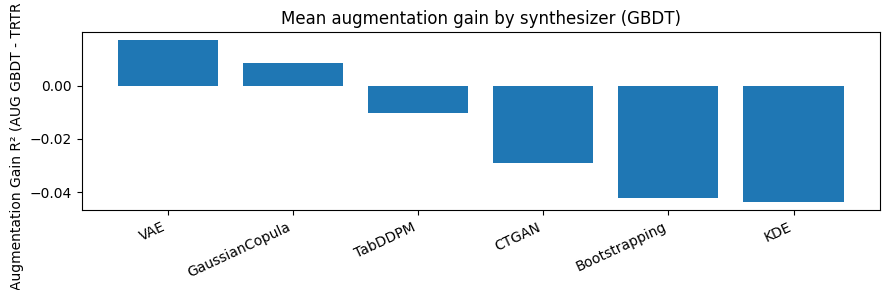

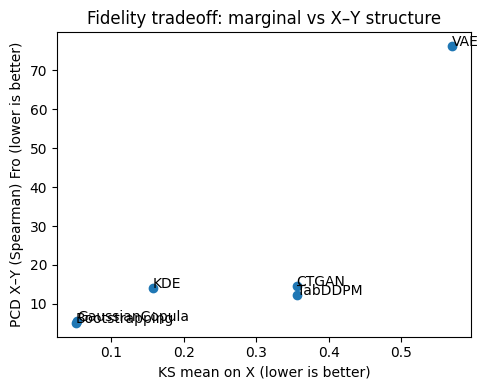

In [17]:

ok = summary.copy()
if len(ok) > 0 and "aug_gain_GBDT_r2_mean_mean" in ok.columns:
    ok = ok.sort_values("aug_gain_GBDT_r2_mean_mean", ascending=False)

    plt.figure(figsize=(9,3))
    plt.bar(ok["synth"], ok["aug_gain_GBDT_r2_mean_mean"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Augmentation Gain R² (AUG GBDT - TRTR GBDT)")
    plt.title("Mean augmentation gain by synthesizer (GBDT)")
    plt.tight_layout()
    plt.show()

    # scatter: KS vs PCD_XY (Spearman)
    if "ksX_ks_mean_mean" in ok.columns and "pcd_xy_fro_spearman_mean" in ok.columns:
        plt.figure(figsize=(5,4))
        plt.scatter(ok["ksX_ks_mean_mean"], ok["pcd_xy_fro_spearman_mean"])
        for _, r in ok.iterrows():
            plt.annotate(r["synth"], (r["ksX_ks_mean_mean"], r["pcd_xy_fro_spearman_mean"]))
        plt.xlabel("KS mean on X (lower is better)")
        plt.ylabel("PCD X–Y (Spearman) Fro (lower is better)")
        plt.title("Fidelity tradeoff: marginal vs X–Y structure")
        plt.tight_layout()
        plt.show()